# Hospital Readmission Risk Predictor — Exploratory Data Analysis
**Author:** Angeline Setiawan &nbsp;|&nbsp; **Team:** Epsilon

This notebook performs exploratory data analysis (EDA) on the Diabetes 130-US Hospitals for Years 1999-2008 dataset, in preparation for the formal EDA report delivered to hospital administration and care management stakeholders.

**Scope of this notebook (per course EDA-stage rules):**
- No full missing-value imputation yet (this is EDA, not final cleaning).
- We DO derive the binary `readmitted_30d` target and a few lightweight, non-destructive engineered fields, because we need them to explore the data meaningfully — this is exploratory scaffolding, not the final preprocessing pipeline.
- We DO drop one clearly non-informative column (`weight`, ~97% missing) as explicitly permitted by the assignment instructions.

**Notebook structure:**
1. Setup & Imports
2. Data Acquisition
3. Initial Data Inventory (shape, types, missingness — no imputation)
4. Minimal EDA-Stage Derivations (binary target, drop non-informative column)
5. Descriptive Statistics — Continuous Variables (Table 1)
6. Descriptive Statistics — Categorical Variables (Table 2)
7. Stratified Summary by Target (Table 3, optional bonus table)
8. Visualizations (5+ figures, each captioned)
9. Collinearity / Correlation Assessment
10. Export Figures & Tables for the Written Report

## 1. Setup & Imports

In [26]:
# ==========================================================
# CORE LIBRARIES
# ==========================================================
import os
import numpy as np
import pandas as pd

# Stats helpers for skew/kurtosis and descriptive summaries
from scipy import stats

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------
# Global plotting style — keep every figure in the report
# visually consistent (font size, palette, grid style).
# --------------------------------------------------------
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# --------------------------------------------------------
# Output folders: keep generated figures/tables separate
# from source data so the report-writer (or teammate) can
# find everything without digging through the notebook.
# --------------------------------------------------------
FIG_DIR = 'outputs/figures'
TAB_DIR = 'outputs/tables'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

## 2. Data Acquisition
The UCI download comes as **two files**:
- `diabetic_data.csv` — the encounter-level dataset (one row per inpatient encounter). This is the file all descriptive stats, tables, and figures below are built from.
- `IDS_mapping.csv` — a small lookup/reference file that decodes three coded ID columns (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) into human-readable labels. It is **not** encounter-level data — it's a reference table, structured as three small tables stacked in one file with a blank line between each.

Two loading options are given for `diabetic_data.csv` — use whichever fits your environment. **Only run one.** The `IDS_mapping.csv` parsing step applies either way.

In [27]:
# ==========================================================
# DATA_DIR — set once to wherever your two CSVs live
# (matches the 'data' folder from the UCI download).
# ==========================================================
DATA_DIR = 'data'

In [28]:
# ==========================================================
# Load the main encounter file from a local CSV, e.g. 
# data/diabetic_data.csv as downloaded from UCI.
# ==========================================================
df_raw = pd.read_csv('../data/raw/diabetic_data.csv')  # relative to notebook location
print(f'Loaded from local CSV: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head()

Loaded from local CSV: 101,766 rows x 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


### 2a. Load & Parse `IDS_mapping.csv` (ID → Label Reference Table)
This file stacks three separate lookup tables — one per coded ID column — with a blank line between each block. We split the raw text on blank-line boundaries into three small DataFrames, then merge readable labels onto the main dataset.

In [29]:
import os
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\angie\Documents\GitHub\hospital-readmission-risk-predictor\AngelineSetiawan-hospital-readmission-risk-predictor\notebooks


In [30]:
# ----------------------------------------------------------------
# Look at the first ~30 lines exactly as read, with repr() to reveal
# hidden characters. Re-reads the file here so this cell is
# self-contained and doesn't depend on earlier cells having been run.
# ----------------------------------------------------------------
import os

DATA_DIR = '../data'
file_path = f'{DATA_DIR}/raw/IDS_mapping.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find {file_path}")

with open(file_path, 'r') as f:
    raw_lines = [line.strip() for line in f.readlines()]

for i, line in enumerate(raw_lines[:30]):
    print(i, repr(line))

0 'admission_type_id,description'
1 '1,Emergency'
2 '2,Urgent'
3 '3,Elective'
4 '4,Newborn'
5 '5,Not Available'
6 '6,NULL'
7 '7,Trauma Center'
8 '8,Not Mapped'
9 ','
10 'discharge_disposition_id,description'
11 '1,Discharged to home'
12 '2,Discharged/transferred to another short term hospital'
13 '3,Discharged/transferred to SNF'
14 '4,Discharged/transferred to ICF'
15 '5,Discharged/transferred to another type of inpatient care institution'
16 '6,Discharged/transferred to home with home health service'
17 '7,Left AMA'
18 '8,Discharged/transferred to home under care of Home IV provider'
19 '9,Admitted as an inpatient to this hospital'
20 '10,Neonate discharged to another hospital for neonatal aftercare'
21 '11,Expired'
22 '12,Still patient or expected to return for outpatient services'
23 '13,Hospice / home'
24 '14,Hospice / medical facility'
25 '15,Discharged/transferred within this institution to Medicare approved swing bed'
26 '16,Discharged/transferred/referred another institution f

In [31]:
print(len(raw_lines))

68


In [32]:
import os

# ----------------------------------------------------------------
# Point DATA_DIR one level up, since the notebook runs from /notebooks
# but the data folder is a sibling of it, not a child.
# ----------------------------------------------------------------
DATA_DIR = '../data'
file_path = f'{DATA_DIR}/raw/IDS_mapping.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"Could not find {file_path}. "
        f"Contents of {DATA_DIR}/raw: "
        f"{os.listdir(f'{DATA_DIR}/raw') if os.path.exists(f'{DATA_DIR}/raw') else 'raw folder not found'}"
    )

# ----------------------------------------------------------------
# Read the raw mapping file as plain text lines so we can split it
# on separator-line boundaries into its three sub-tables.
# Separator lines are blank, or a bare comma (',') left over from
# an empty two-column CSV row - both count as a table break.
# ----------------------------------------------------------------
with open(file_path, 'r') as f:
    raw_lines = [line.strip() for line in f.readlines()]

blocks, current = [], []
for line in raw_lines:
    if line.strip(',').strip() == '':  # catches '', ',', ' , ', etc.
        if current:
            blocks.append(current)
        current = []
    else:
        current.append(line)
if current:
    blocks.append(current)

print(f'Found {len(blocks)} lookup sub-tables in IDS_mapping.csv')

Found 3 lookup sub-tables in IDS_mapping.csv


### 2a. Load & Parse `IDS_mapping.csv` (ID → Label Reference Table)
This file stacks three separate lookup tables — one per coded ID column — with a blank line between each block. We split the raw text on blank-line boundaries into three small DataFrames, then merge readable labels onto the main dataset.

In [33]:
import os

DATA_DIR = '../data'
file_path = f'{DATA_DIR}/raw/IDS_mapping.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"Could not find {file_path}. "
        f"Contents of {DATA_DIR}/raw: "
        f"{os.listdir(f'{DATA_DIR}/raw') if os.path.exists(f'{DATA_DIR}/raw') else 'raw folder not found'}"
    )

# ----------------------------------------------------------------
# Read the raw mapping file as plain text lines so we can split it
# on separator-line boundaries into its three sub-tables.
# Separator lines are blank, or a bare comma (',') left over from
# an empty two-column CSV row - both count as a table break.
# ----------------------------------------------------------------
with open(file_path, 'r') as f:
    raw_lines = [line.strip() for line in f.readlines()]

blocks, current = [], []
for line in raw_lines:
    if line.strip(',').strip() == '':
        if current:
            blocks.append(current)
        current = []
    else:
        current.append(line)
if current:
    blocks.append(current)

print(f'Found {len(blocks)} lookup sub-tables in IDS_mapping.csv')

Found 3 lookup sub-tables in IDS_mapping.csv


In [34]:
# ----------------------------------------------------------------
# Convert each text block into its own small DataFrame. Column names
# come from each block's own header row (first line of the block),
# so this stays robust even if exact wording differs slightly from
# what we expect.
# ----------------------------------------------------------------
import io

id_lookup_tables = {}
for block in blocks:
    block_df = pd.read_csv(io.StringIO('\n'.join(block)), keep_default_na=False)
    id_col = block_df.columns[0]          # e.g. 'admission_type_id'
    id_lookup_tables[id_col] = block_df
    print(f'  - {id_col}: {len(block_df)} categories')

# Preview one parsed lookup table
next(iter(id_lookup_tables.values()))

  - admission_type_id: 8 categories
  - discharge_disposition_id: 30 categories
  - admission_source_id: 25 categories


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NULL
6,7,Trauma Center
7,8,Not Mapped


In [35]:
# ----------------------------------------------------------------
# Merge readable *_label columns onto df_raw for each ID field we
# have a lookup table for. The ORIGINAL coded ID columns are kept
# untouched (the proposal's Data Dictionary marks them as coded
# categorical predictors for modeling) — the label is added as a
# new, separate column purely to make EDA tables/plots readable.
# ----------------------------------------------------------------
for id_col, lookup_df in id_lookup_tables.items():
    if id_col in df_raw.columns:
        desc_col = lookup_df.columns[1]                 # e.g. 'description'
        renamed = lookup_df.rename(columns={desc_col: f'{id_col}_label'})
        df_raw = df_raw.merge(renamed, on=id_col, how='left')

new_label_cols = [c for c in df_raw.columns if c.endswith('_label')]
print('Added readable label columns:', new_label_cols)
df_raw[[*id_lookup_tables.keys(), *new_label_cols]].head()

Added readable label columns: ['admission_type_id_label', 'discharge_disposition_id_label', 'admission_source_id_label']


,admission_type_id,discharge_disposition_id,admission_source_id,admission_type_id_label,discharge_disposition_id_label,admission_source_id_label
0,6,25,1,NULL,Not Mapped,Physician Referral
1,1,1,7,Emergency,Discharged to home,Emergency Room
2,1,1,7,Emergency,Discharged to home,Emergency Room
3,1,1,7,Emergency,Discharged to home,Emergency Room
4,1,1,7,Emergency,Discharged to home,Emergency Room


## 3. Initial Data Inventory
Per assignment rules for this stage: **inspect** missingness and dtypes, but do **not** impute or drop rows for missing values yet. The dataset encodes missing values as the string `"?"` rather than a true null, so we standardize that representation here for accurate counting only — the values themselves are left untouched. Note: the `*_label` columns added in Section 2a can show their own small number of nulls if a code in `diabetic_data.csv` has no matching row in `IDS_mapping.csv` (e.g., an 'unmapped' or reserved code) — that's a mapping gap, not missingness in the original data, and is worth a one-line mention in the report rather than being conflated with the '?' fields below.

In [36]:
# ----------------------------------------------------------------
# Standardize the dataset's '?' missing-value placeholder to NaN so
# pandas' built-in missingness tools (isna, info) report correctly.
# NOTE: this is a *representation* fix, not imputation — no values
# are filled in or dropped here.
# ----------------------------------------------------------------
df = df_raw.replace('?', np.nan).copy()

print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes.value_counts())

Shape: (101766, 53)

Data types:
object    40
int64     13
Name: count, dtype: int64


In [37]:
# ----------------------------------------------------------------
# Missingness inventory — % missing per column, worst offenders first.
# This directly informs the Data Cleaning & Preprocessing Plan section
# of the written report (e.g., which fields need imputation strategy,
# which are candidates to drop as non-informative).
# ----------------------------------------------------------------
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = missing_pct[missing_pct > 0].round(2).to_frame('pct_missing')
missing_summary.to_csv(f'{TAB_DIR}/missingness_inventory.csv')
missing_summary

,pct_missing
weight,96.86
max_glu_serum,94.75
A1Cresult,83.28
medical_specialty,49.08
payer_code,39.56
race,2.23
diag_3,1.40
diag_2,0.35
diag_1,0.02


## 4. Minimal EDA-Stage Derivations
We create the binary target and drop exactly one column (`weight`, ~97% missing, explicitly non-informative at this sample size). No other cleaning is performed here — the full preprocessing pipeline (diagnosis-code grouping, encoding, class-imbalance handling, time-aware/patient-grouped splitting) is documented separately in the Analysis Plan and implemented later, not during EDA.

In [38]:
# ----------------------------------------------------------------
# TARGET DERIVATION
# Native `readmitted` is 3-class: '<30', '>30', 'NO'.
# We collapse it to a binary target for the classification task:
#   1 = readmitted within 30 days
#   0 = not readmitted within 30 days (readmitted later, or not at all)
# ----------------------------------------------------------------
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

print('Target class balance:')
print(df['readmitted_30d'].value_counts(normalize=True).round(4) * 100)

Target class balance:
readmitted_30d
0    88.84
1    11.16
Name: proportion, dtype: float64


In [39]:
# ----------------------------------------------------------------
# DROP NON-INFORMATIVE COLUMN
# `weight` is missing for ~97% of encounters — explicitly allowed to
# drop at the EDA stage per assignment instructions ('you may drop
# non-informative variables'). Everything else with missing data is
# left as-is for now.
# ----------------------------------------------------------------
if 'weight' in df.columns:
    df = df.drop(columns=['weight'])
    print('Dropped: weight (non-informative, ~97% missing)')

Dropped: weight (non-informative, ~97% missing)


## 5. Descriptive Statistics — Continuous Variables (Table 1)
Per the rubric: mean/median (central tendency), spread, and distribution shape (skew & kurtosis) for the core continuous predictors plus the target. Limited to the ~20-25 key variables most relevant to the hypothesis, per assignment guidance for high-dimensional datasets.

In [40]:
# ----------------------------------------------------------------
# KEY VARIABLE LIST
# Centralized here so it's easy to find/edit — used by every
# descriptive-stats and visualization cell below.
# ----------------------------------------------------------------
CONTINUOUS_VARS = [
    'time_in_hospital',      # core to hypothesis
    'num_lab_procedures',
    'num_procedures',
    'num_medications',       # core to hypothesis
    'number_outpatient',     # core to hypothesis (prior utilization)
    'number_emergency',      # core to hypothesis (prior utilization)
    'number_inpatient',      # core to hypothesis (prior utilization)
    'number_diagnoses',
]

CATEGORICAL_VARS = [
    'race', 'gender', 'age',
    # Use the *_label columns merged in from IDS_mapping.csv (Section 2a)
    # instead of raw numeric codes — far more readable in a stakeholder table.
    # The original coded *_id columns are still in `df` if needed for modeling.
    'admission_type_id_label', 'discharge_disposition_id_label', 'admission_source_id_label',
    'max_glu_serum', 'A1Cresult',
    'change', 'diabetesMed',
    'insulin', 'metformin',
]

TARGET = 'readmitted_30d'


In [41]:
# ----------------------------------------------------------------
# Build Table 1: continuous-variable descriptive statistics.
# Includes mean, median, std (spread), skew, and kurtosis (shape).
# ----------------------------------------------------------------
def describe_continuous(data, cols):
    rows = []
    for c in cols:
        series = data[c].dropna()
        rows.append({
            'variable': c,
            'n': series.shape[0],
            'mean': series.mean(),
            'median': series.median(),
            'std': series.std(),
            'min': series.min(),
            'max': series.max(),
            'skew': stats.skew(series),
            'kurtosis': stats.kurtosis(series),   # excess kurtosis (0 = normal-like)
        })
    return pd.DataFrame(rows).set_index('variable').round(2)

table1_continuous = describe_continuous(df, CONTINUOUS_VARS)
table1_continuous.to_csv(f'{TAB_DIR}/table1_continuous_descriptives.csv')
table1_continuous

,n,mean,median,std,min,max,skew,kurtosis
variable,,,,,,,,
time_in_hospital,101766,4.40,4.0,2.99,1,14,1.13,0.85
num_lab_procedures,101766,43.10,44.0,19.67,1,132,-0.24,-0.25
num_procedures,101766,1.34,1.0,1.71,0,6,1.32,0.86
num_medications,101766,16.02,15.0,8.13,1,81,1.33,3.47
number_outpatient,101766,0.37,0.0,1.27,0,42,8.83,147.90
number_emergency,101766,0.20,0.0,0.93,0,76,22.86,1191.63
number_inpatient,101766,0.64,0.0,1.26,0,21,3.61,20.72
number_diagnoses,101766,7.42,8.0,1.93,1,16,-0.88,-0.08


## 6. Descriptive Statistics — Categorical Variables (Table 2)
Frequencies, proportions, and percentages for each key categorical field.

In [42]:
# ----------------------------------------------------------------
# Build Table 2: categorical-variable frequency table.
# One row per (variable, category) pair — long format is easiest
# to scan and to drop straight into a Word/PDF report table.
# ----------------------------------------------------------------
def describe_categorical(data, cols):
    rows = []
    for c in cols:
        counts = data[c].value_counts(dropna=False)
        pct = data[c].value_counts(normalize=True, dropna=False) * 100
        for level in counts.index:
            rows.append({
                'variable': c,
                'level': level,
                'count': counts[level],
                'pct': round(pct[level], 2),
            })
    return pd.DataFrame(rows)

table2_categorical = describe_categorical(df, CATEGORICAL_VARS)
table2_categorical.to_csv(f'{TAB_DIR}/table2_categorical_descriptives.csv', index=False)
table2_categorical.head(30)   # preview — full table saved to CSV above


,variable,level,count,pct
0,race,Caucasian,76099,74.78
1,race,AfricanAmerican,19210,18.88
2,race,NaN,2273,2.23
3,race,Hispanic,2037,2.00
4,race,Other,1506,1.48
5,race,Asian,641,0.63
6,gender,Female,54708,53.76
7,gender,Male,47055,46.24
8,gender,Unknown/Invalid,3,0.00
9,age,[70-80),26068,25.62


## 7. Stratified Summary by Target (Table 3 — bonus/optional)
Mean of each key continuous predictor, split by readmission outcome. This is the table that most directly speaks to the hypothesis: do readmitted patients look 'sicker' on utilization variables?

In [43]:
# ----------------------------------------------------------------
# Table 3: continuous predictor means, stratified by target class.
# Directly tests the hypothesis narrative (utilization/complexity
# variables differing by readmission outcome).
# ----------------------------------------------------------------
table3_stratified = (
    df.groupby(TARGET)[CONTINUOUS_VARS]
      .agg(['mean', 'median'])
      .round(2)
)
table3_stratified.to_csv(f'{TAB_DIR}/table3_stratified_by_target.csv')
table3_stratified

time_in_hospital        num_lab_procedures        num_procedures        num_medications        number_outpatient         \
                           mean median               mean median           mean median            mean median              mean median   
readmitted_30d                                                                                                                           
0                          4.35    4.0              42.95   44.0           1.35    1.0           15.91   15.0              0.36    0.0   
1                          4.77    4.0              44.23   45.0           1.28    1.0           16.90   16.0              0.44    0.0   

               number_emergency        number_inpatient        number_diagnoses         
                           mean median             mean median             mean median  
readmitted_30d                                                                          
0                          0.18    0.0             0.56    0.0             7.39    8.0  
1                          0.36    0.0             1.22    0.0             7.69    9.0

## 8. Visualizations
Five+ figures below, each saved to `outputs/figures/` with a filename matching its figure number for easy reference in the written report.

### Figure 1 — Target Class Balance

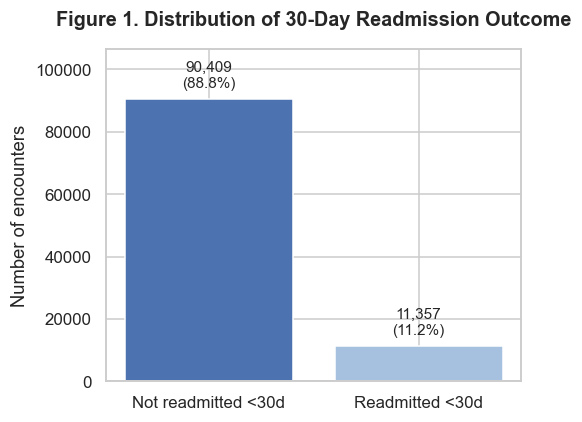

In [44]:
# ----------------------------------------------------------------
# FIGURE 1: Class balance of the binary target.
# Purpose: show reviewers *why* AUC-ROC/recall (not accuracy) are
# the right evaluation metrics later — the positive class is small.
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET].value_counts().sort_index()
labels = ['Not readmitted <30d', 'Readmitted <30d']

# Same steel-blue family as Figure 2
colors = ['#4C72B0', '#A6C1E0']

ax.bar(labels, counts.values, color=colors)

for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.03, f'{v:,}\n({v/counts.sum()*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)

ax.set_title('Figure 1. Distribution of 30-Day Readmission Outcome', pad=15)
ax.set_ylabel('Number of encounters')
ax.set_ylim(0, counts.max() * 1.18)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_target_balance.png', bbox_inches='tight')
plt.show()

### Figure 2 — Distributions of Key Continuous Predictors

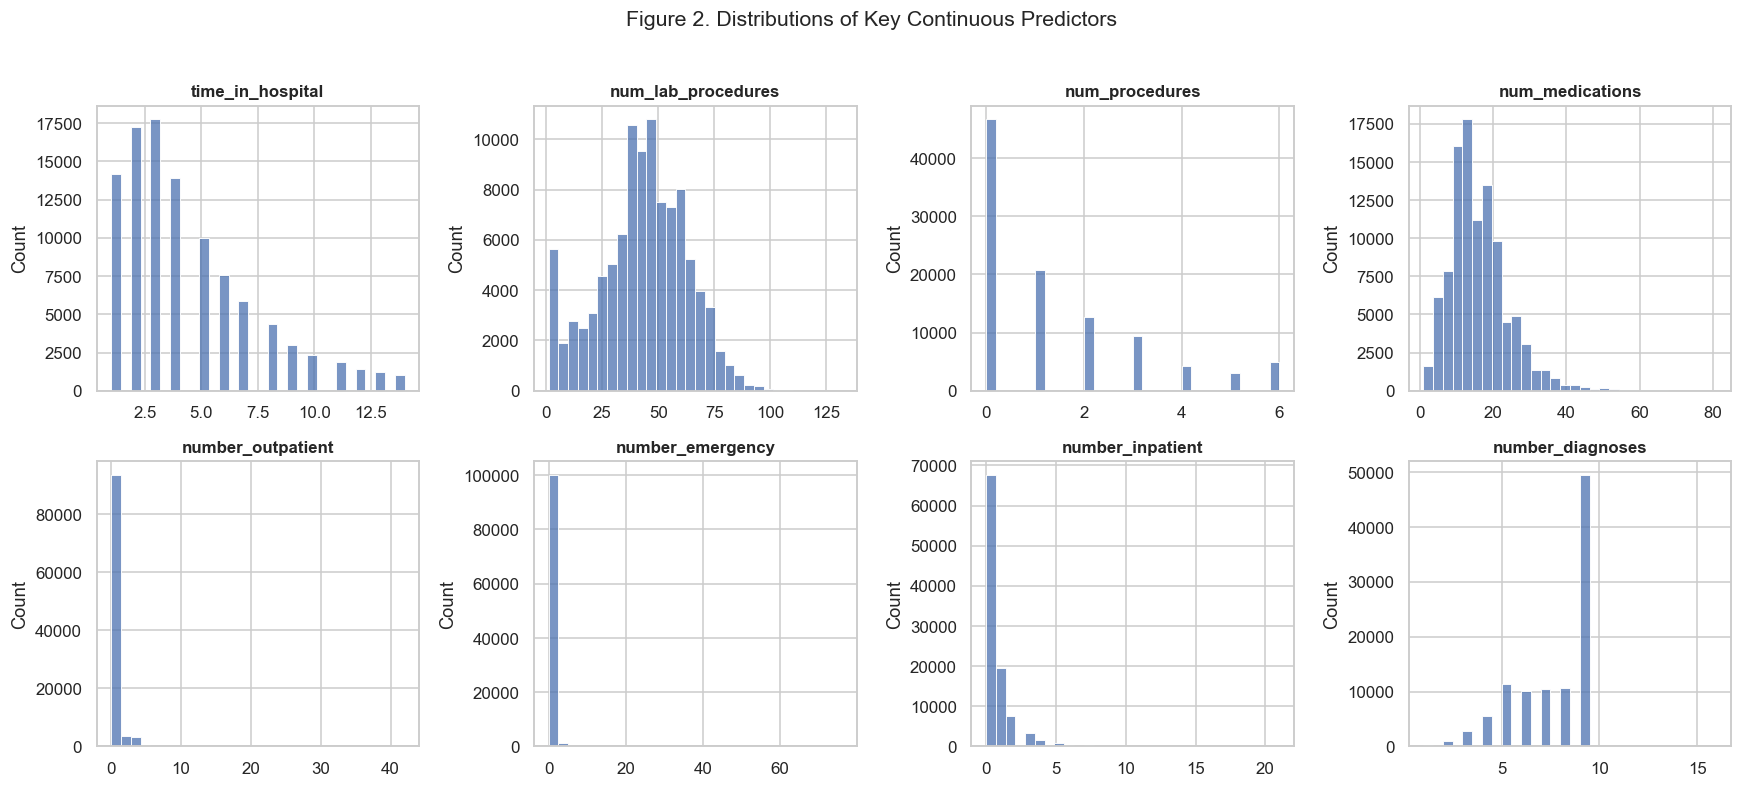

In [45]:
# ----------------------------------------------------------------
# FIGURE 2: Histogram grid for core continuous predictors.
# Purpose: check shape/skew visually (complements Table 1's
# numeric skew/kurtosis) and spot obvious outliers or coding
# artifacts (e.g., capped values).
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), CONTINUOUS_VARS):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
fig.suptitle('Figure 2. Distributions of Key Continuous Predictors', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_continuous_distributions.png', bbox_inches='tight')
plt.show()

### Figure 3 — Key Predictors by Readmission Outcome

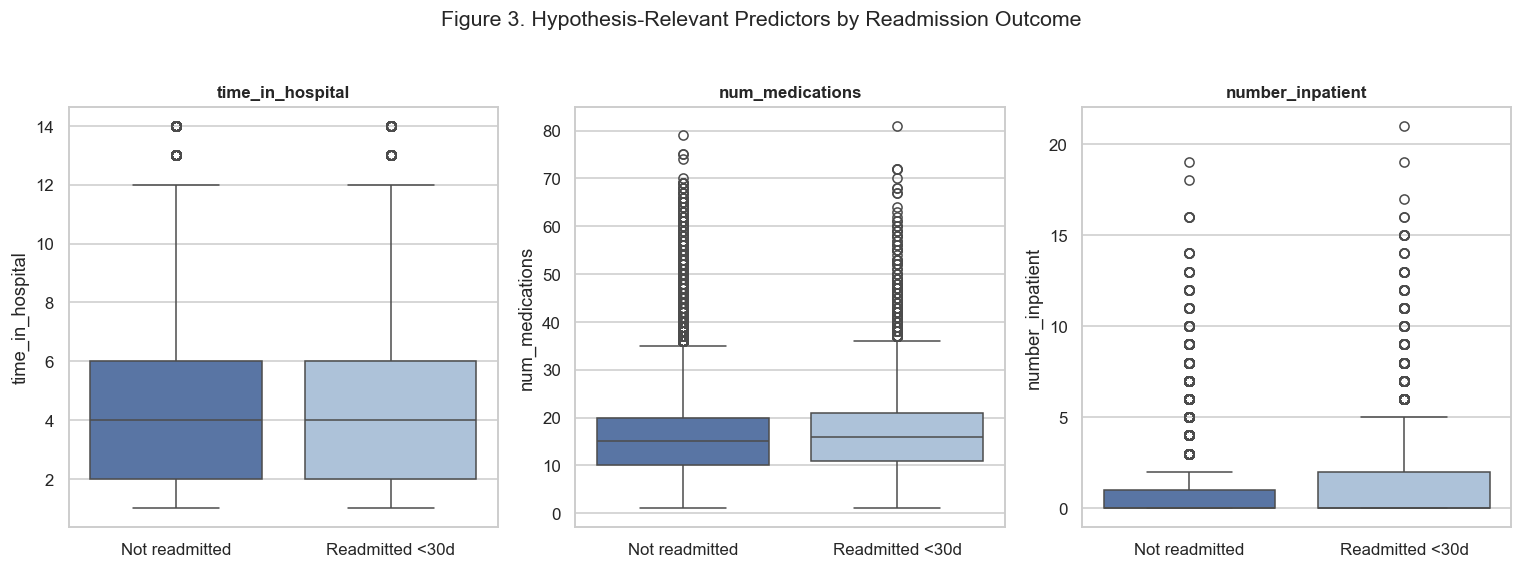

In [46]:
# ----------------------------------------------------------------
# FIGURE 3: Boxplots of core utilization variables, split by target.
# Purpose: direct visual test of the hypothesis — do readmitted
# patients show higher utilization/complexity?
# ----------------------------------------------------------------
hypothesis_vars = ['time_in_hospital', 'num_medications', 'number_inpatient']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = ['#4C72B0', '#A6C1E0']

for ax, col in zip(axes, hypothesis_vars):
    sns.boxplot(x=TARGET, y=col, data=df, ax=ax, hue=TARGET,
                palette=colors, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Not readmitted', 'Readmitted <30d'])
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')

fig.suptitle('Figure 3. Hypothesis-Relevant Predictors by Readmission Outcome', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_predictors_by_outcome.png', bbox_inches='tight')
plt.show()

### Figure 4 — Readmission Rate by Age Bracket

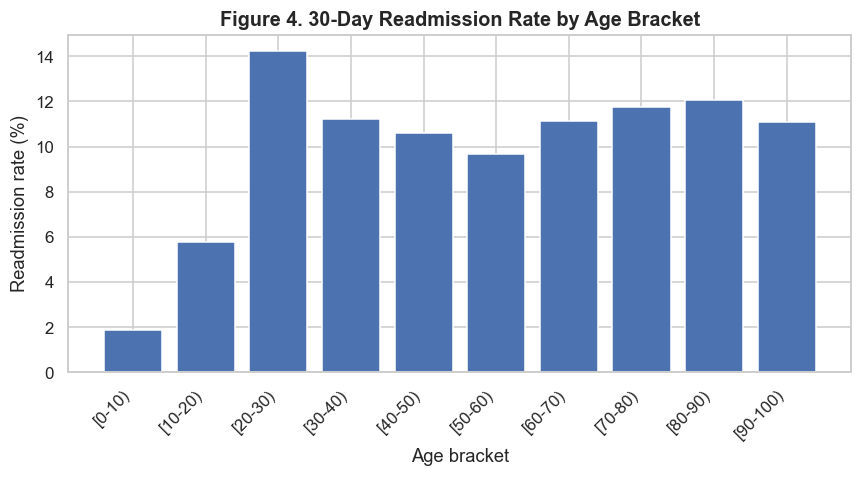

In [47]:
# ----------------------------------------------------------------
# FIGURE 4: Readmission RATE (not raw count) by age bracket.
# Purpose: check whether age is a meaningful demographic predictor
# — using rate (not count) avoids the plot simply reflecting which
# age brackets have more encounters overall.
# ----------------------------------------------------------------
age_order = sorted(df['age'].dropna().unique(),
                    key=lambda x: int(x.strip('[)').split('-')[0]))
readmit_rate_by_age = df.groupby('age')[TARGET].mean().reindex(age_order) * 100

fig, ax = plt.subplots(figsize=(8, 4.5))

# Same steel-blue family as Figures 1-3
ax.bar(readmit_rate_by_age.index, readmit_rate_by_age.values, color='#4C72B0')

ax.set_title('Figure 4. 30-Day Readmission Rate by Age Bracket')
ax.set_ylabel('Readmission rate (%)')
ax.set_xlabel('Age bracket')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_readmit_rate_by_age.png', bbox_inches='tight')
plt.show()


### Figure 5 — Readmission Rate by Prior Inpatient Visit Count

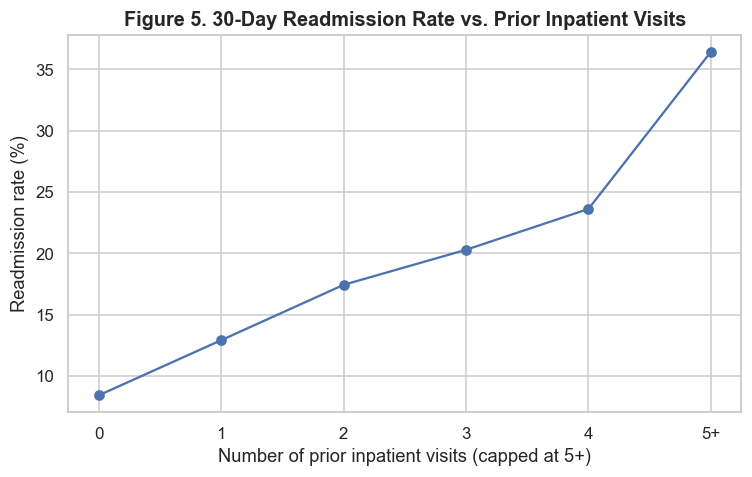

In [48]:
# ----------------------------------------------------------------
# FIGURE 5: Readmission rate as prior inpatient visits increase.
# Purpose: this is the single clearest test of the hypothesis —
# a monotonic upward trend directly supports 'more complex care
# history -> higher readmission risk.'
# ----------------------------------------------------------------
# Cap at 5+ prior visits to avoid a long, sparse, hard-to-read tail
df['_number_inpatient_capped'] = df['number_inpatient'].clip(upper=5).astype(int)
rate_by_prior = df.groupby('_number_inpatient_capped')[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))

# Same steel-blue family as Figures 1-4
ax.plot(rate_by_prior.index, rate_by_prior.values, marker='o', color='#4C72B0')

ax.set_xticks(rate_by_prior.index)
ax.set_xticklabels([str(i) if i < 5 else '5+' for i in rate_by_prior.index])
ax.set_title('Figure 5. 30-Day Readmission Rate vs. Prior Inpatient Visits')
ax.set_xlabel('Number of prior inpatient visits (capped at 5+)')
ax.set_ylabel('Readmission rate (%)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig5_readmit_rate_by_prior_inpatient.png', bbox_inches='tight')
plt.show()

## 9. Collinearity Assessment (Figure 6 — required)
Correlation matrix + correlogram (heatmap) across the core continuous predictors. This directly informs whether any features should be combined, dropped, or regularized against before modeling.

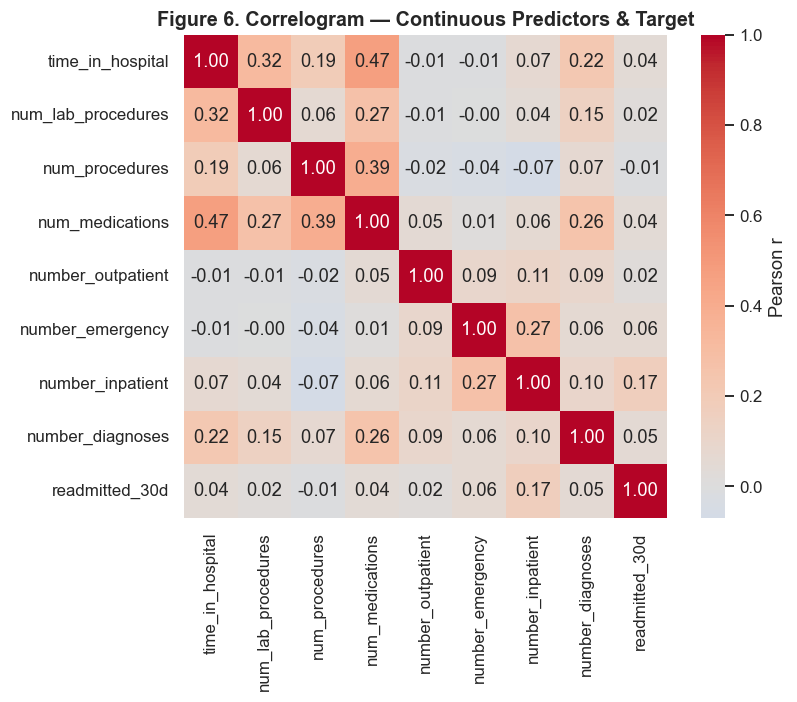

In [49]:
# ----------------------------------------------------------------
# FIGURE 6: Correlogram (correlation heatmap) of continuous predictors.
# Purpose: flag pairs of features that are highly correlated with
# each other (redundant signal / multicollinearity risk for the
# logistic regression baseline in particular).
# ----------------------------------------------------------------
corr_matrix = df[CONTINUOUS_VARS + [TARGET]].corr(method='pearson').round(2)
corr_matrix.to_csv(f'{TAB_DIR}/correlation_matrix.csv')

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, cbar_kws={'label': 'Pearson r'}, ax=ax
)
ax.set_title('Figure 6. Correlogram — Continuous Predictors & Target')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig6_correlogram.png', bbox_inches='tight')
plt.show()

## 10. Export Summary
All tables were saved to `outputs/tables/` and all figures to `outputs/figures/` as each cell ran. To hand this off for the written report:

1. Run the whole notebook top to bottom (Kernel → Restart & Run All) so outputs are current.
2. **File → Save and Export Notebook As → PDF** (or run `jupyter nbconvert --to pdf EDA_Hospital_Readmission.ipynb` from a terminal).
3. Send the exported PDF (and, if easy, the `outputs/` folder) back — the report will be written directly from these real tables and figures.

In [50]:
# ----------------------------------------------------------------
# Quick sanity check: confirm everything that should exist, does.
# ----------------------------------------------------------------
print('Tables written:')
for f in sorted(os.listdir(TAB_DIR)):
    print('  -', f)
print()
print('Figures written:')
for f in sorted(os.listdir(FIG_DIR)):
    print('  -', f)

Tables written:
  - correlation_matrix.csv
  - missingness_inventory.csv
  - table1_continuous_descriptives.csv
  - table2_categorical_descriptives.csv
  - table3_stratified_by_target.csv

Figures written:
  - fig1_target_balance.png
  - fig2_continuous_distributions.png
  - fig3_predictors_by_outcome.png
  - fig4_readmit_rate_by_age.png
  - fig5_readmit_rate_by_prior_inpatient.png
  - fig6_correlogram.png
